**Prevendo atrasos de voos ✈
Nosso case a ser analisado na aula de hoje é um dataset que contém algumas características sobre informações de voos.

Nosso foco basicamente consiste em prever se um determinado voo sofrerá atrasos, a partir da informação da partida programada.

Flight: Número do voo.

Time: Horário de partida do voo.

Length: Duração do voo.

Airline: Nome do avião.

AirportFrom: Partida.

AirportTo: Destino.

DayOfWeek: Dia da semana

Class: Classe de atraso.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [3]:
#Importando a base de dados

df = pd.read_csv("airlines.csv", sep =',')

In [4]:
#Analisando as primeiras linhas
df.head(3)

,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
0,2313.0,1296.0,141.0,DL,ATL,HOU,1,0
1,6948.0,360.0,146.0,OO,COS,ORD,4,0
2,1247.0,1170.0,143.0,B6,BOS,CLT,3,0


In [5]:
# Analisando linhas e colunas
df.shape

(539382, 8)

---Analisando inconsistencias dos dados

In [6]:
#Analisando valores nulos
df.isnull().sum()

Flight         0
Time           0
Length         0
Airline        0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Class          0
dtype: int64

In [7]:
#limpando dados nulos --- Não possue dados nulos na base de dados, mas caso tivesse, poderia ser feito da seguinte forma:
df = df.dropna()

 Analisando dados duplicados

In [8]:
#Duplicado nem sempre é coisa ruim, podemos considerar o cpmportamento normal pois podemos ter vários casos com o mesmo valor na base

duplicated_cols = []
for col in df.columns:
    if df[col].duplicated().any():
        duplicated_cols.append(col)
print("Colunas com valores duplicados:", duplicated_cols)

Colunas com valores duplicados: ['Flight', 'Time', 'Length', 'Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Class']


Análise Exploratória dos dados

In [9]:
df.describe().T. round(2)

# INFERÊNCIA

# Média de duração dos voos é de 133
#desvio padrão: 70
# Se o desvio padrão é baxio em relação a média, significa que os dados estão concentrados em torno da média.

,count,mean,std,min,25%,50%,75%,max
Flight,539382.0,2427.93,2067.43,1.0,712.0,1809.0,3745.0,7814.0
Time,539382.0,802.73,278.05,10.0,565.0,795.0,1035.0,1439.0
Length,539382.0,132.20,70.12,0.0,81.0,115.0,162.0,655.0
DayOfWeek,539382.0,3.93,1.91,1.0,2.0,4.0,5.0,7.0
Class,539382.0,0.45,0.50,0.0,0.0,0.0,1.0,1.0


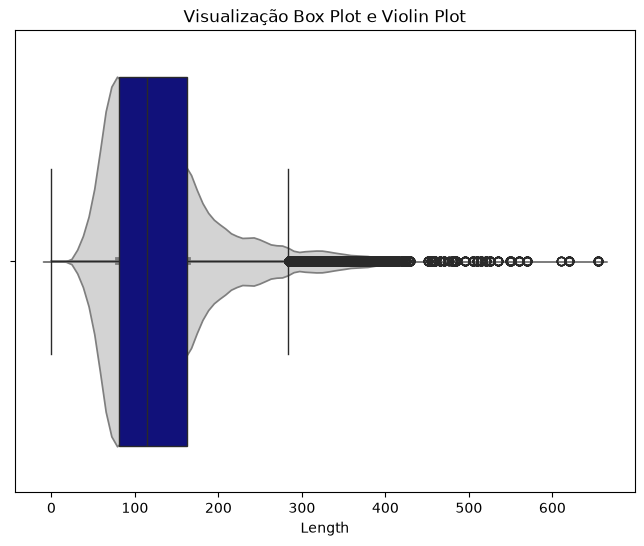

In [10]:
#Violin e Boxplot

#mesclando dados para entendr os valores discrepantes 
fig, ax = plt.subplots(figsize=(8,6))
# configuração do violin plot primeiramente
sns.violinplot(x= 'Length', data= df, ax = ax, color ='lightgray')
#por baixo vamos colocar o boxplot
sns.boxplot(x='Length', data= df, ax= ax, whis=1.5, color='darkblue')
ax.set_title('Visualização Box Plot e Violin Plot')
plt.show()


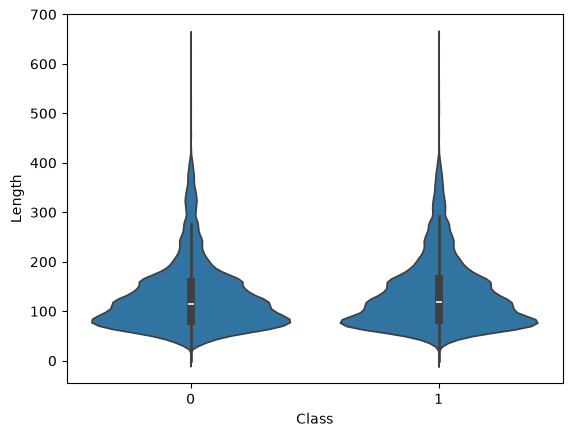

In [11]:
# Verificando o tempo do voo para cada classe, mas não há diferença
sns.violinplot(x='Class', y='Length', data = df)
plt.show()
           

In [12]:
atraso_voo = df.groupby('Class')
atraso_voo.describe().T.round(2)

Class                    0          1
Flight    count  299118.00  240264.00
          mean     2513.48    2321.41
          std      2102.88    2017.37
          min         1.00       1.00
          25%       725.00     701.00
          50%      1924.00    1695.00
          75%      3931.00    3408.00
          max      7812.00    7814.00
Time      count  299118.00  240264.00
          mean      765.24     849.41
          std       283.71     263.47
          min        10.00      10.00
          25%       515.00     640.00
          50%       735.00     860.00
          75%       998.00    1060.00
          max      1439.00    1439.00
Length    count  299118.00  240264.00
          mean      129.66     135.37
          std        68.69      71.72
          min         0.00       0.00
          25%        81.00      82.00
          50%       114.00     118.00
          75%       159.00     166.00
          max       655.00     655.00
DayOfWeek count  299118.00  240264.00
          mean        3.97       3.87
          std         1.91       1.92
          min         1.00       1.00
          25%         2.00       2.00
          50%         4.00       4.00
          75%         5.00       5.00
          max         7.00       7.00

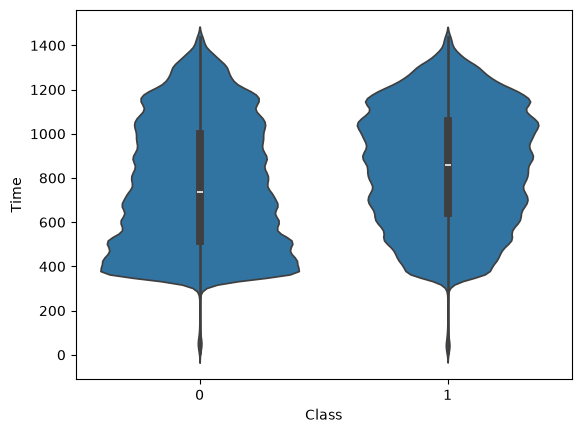

In [13]:
#tIME X Class
sns.violinplot(x='Class', y = 'Time', data = df)
plt.show()

<Axes: xlabel='Airline', ylabel='count'>

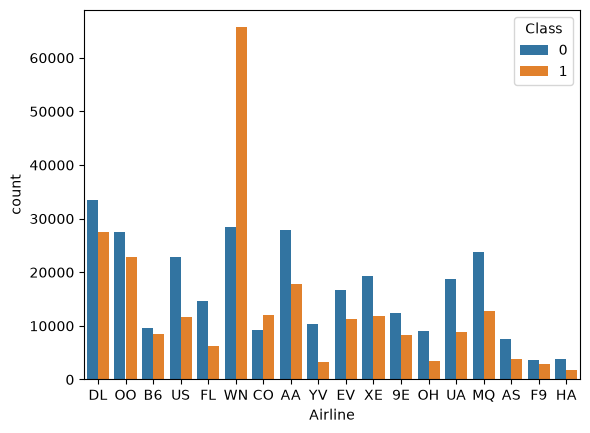

In [14]:
#Analisando companhias de voo X atraso
sns.countplot(x='Airline', hue='Class', data = df)

<Axes: xlabel='DayOfWeek', ylabel='count'>

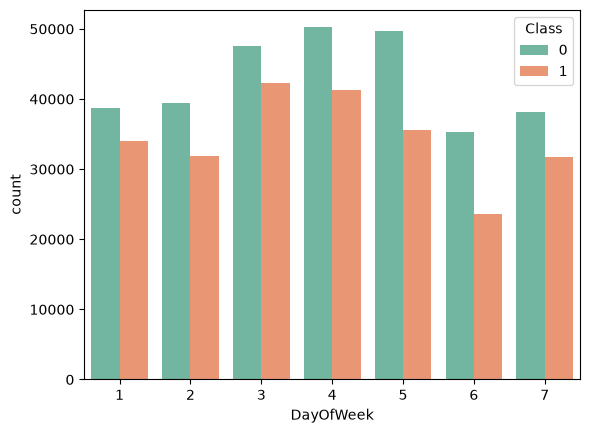

In [15]:
diaSemana = list(range(1,8))
sns.countplot(x='DayOfWeek', data = df, hue = 'Class',palette = 'Set2', order = diaSemana)

<Axes: xlabel='Class', ylabel='count'>

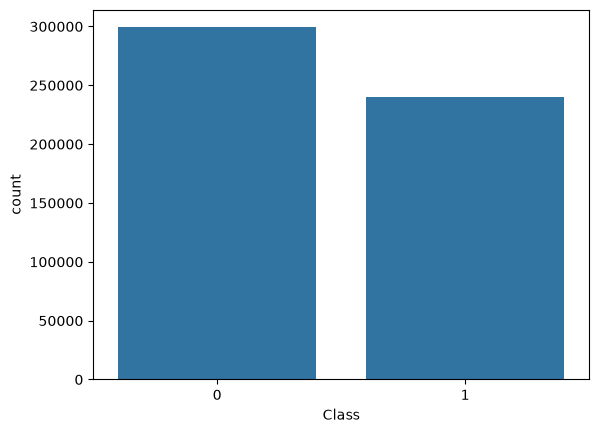

In [16]:
#Avaliando a distribuição de classes, o modelo irá entender que a gnt não atrasa tanto pois o dataset está desbalanceado, então vamos balancear a base de dados para que o modelo consiga aprender melhor.
sns.countplot(x='Class', data = df)  # COlOCAR NO NOSSO TECH CHALLENGE QUE O MODELO NÃO CONSEGUE APRENDER COM BASE DESBALANCEADA, ENTÃO VAMOS BALANCEAR A BASE DE DADOS PARA QUE O MODELO CONSIGA APRENDER MELHOR.

PRÉ PROCESSAMENTO DE BASE - LABEL ECONDING NOS DADOS POIS SE EU QUISER UTILIZAR UMA VARIAVEL CATEGORICA PRECISO COLOCAR ELA EM NÚMERICA POIS O COMPUTADOR NÃO ENTENDE

In [17]:
#Para utilizar a companhia area dentro do modelo, vamor realizar a transformação de label enconding dentro dos dados
from sklearn.preprocessing import LabelEncoder

In [18]:
df['AirportFrom'] = LabelEncoder().fit_transform(df['AirportFrom'])
df['AirportTo'] = LabelEncoder().fit_transform(df['AirportTo'])



In [19]:
df['Airline'] = LabelEncoder().fit_transform(df['Airline'])

In [20]:
df.head(3)

,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
0,2313.0,1296.0,141.0,5,16,129,1,0
1,6948.0,360.0,146.0,12,65,208,4,0
2,1247.0,1170.0,143.0,3,35,60,3,0


SEPARANDO OS DADOS

In [21]:
from sklearn.model_selection import train_test_split

x= df[['Flight', 'Time', 'Length', 'Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek']]
y = df['Class']

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.3, random_state = 7) # ramdom_state = semente aleatória, para que sempre que rodar o código, ele gere os mesmos resultados.

****Criando o modelo de naive bayes
Naive Bayes é um algortimo baseado no teorema de Bayes e na suposição de independência condicional entre atributos.

O modelo Naive Bayes calcula a probabilidade condicional de uma determinada classe, dada uma entrada de dados ou conjunto de atributos, utilizando a regra de Bayes.

Ele assume que os atributos de entrada são independentes entre si, ou seja, a presença ou ausência de um atributo não é afetada pela presença ou ausência de outro atributo

In [23]:
from sklearn.naive_bayes import GaussianNB

In [24]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[209279.,168288.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.55,0.45]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.004278
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Flight','Time','Length',...,'AirportFrom','AirportTo','DayOfWeek']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 7)","[[2513.17, 765.76, 129.65,..., 142.72, 140.52, 3.98], [2324.76, 849.7 , 135.51,..., 145.74, 148.42, 3.87]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 7)","[[4420626.2 , 80535.62, 4708.17,..., 6349.55, 6206.09, 3.65], [4080770.03, 69403.95, 5161.22,..., 6267.24, 6359.56, 3.7 ]]"


In [25]:
#Predizendo Valores
y_pred = gnb.predict(x_test)

VALIDANDO O MODELO

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
acurracy = accuracy_score(y_test, y_pred)
print("Acurracia do modelo:", round(acurracy,2))

Acurracia do modelo: 0.59


De modo geral, o modelo não obteve um poder preditivo grande...

Nessa caso, podemos encontrar alguns desafios (limtações) sobre os modelos classficadores.

Podemos ter alguns impedimentos que podem ocasionar resultados ruins em nossos algoritmos, sendo eles: Algoritmos ruins ou dados ruins.

Vamos conversar um pouquinho sobre esses desafios! Se tratando de dados ruins, podemos ter alguns fatores:

Quantidade insuficiente de dados: Com uma amostra de dados muito pequena, existirá um "ruído de amostragem" e se houver uma amostra muito grande com dados não representativos, o método de amostragem também pode ser falho (Viés de amostragem).

Dados de treinamento não representativos: O objetivo de um bom modelo de aprendizado de máquina é generalizar bem a partir dos dados de treinamento, sendo assim, é importante buscar uma base de dados representativa. Será que a sua base de dados consegue generalizar?

Dados de baixa qualidade: Aqui é preciso se dedicar a limpeza dos dados, uma base não consistente pode impactar na detecção de padrões.

Características irrelevantes: Entra lixo, sai lixo. Atenção aos dados que entram no seu modelo! A dica aqui é a dedicação na etapa de feature engineering ou técnicas de redução de dimensionalidade.

In [28]:
# --------- Equilibrando os dados ( quando uma classe está sobressaindo uma da outra)
#Duplicar dados já existentes da classe minoritária para que o modelo consiga aprender melhor, pois a base de dados está desbalanceada.
from sklearn.utils import resample


In [29]:
#Separando as classes majoritárias e minoritárias
df_majority = df[df['Class'] == 0]  # Classe majoritária (não atrasado)
df_minority = df[df['Class'] == 1]  # Classe minoritária (atrasado)


In [30]:
# quantidade de valores em cada classe
len(df_majority), len(df_minority)

(299118, 240264)

In [31]:
#Usampling da classe minoritária
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state = 7)

In [32]:
#Mesma qtd de váriaveis em cada classe --- Depois de Tunar a variável, o modelo consegue aprender melhor, pois a base de dados está desbalanceada.

len(df_majority), len(df_minority_upsampled)

(299118, 299118)

In [33]:
#Juntando os dataframes
df_equilibrado = pd.concat([df_majority, df_minority_upsampled])



<Axes: xlabel='Class', ylabel='count'>

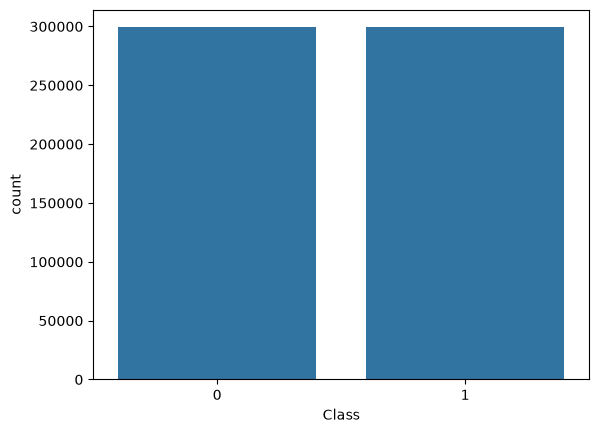

In [34]:
sns.countplot(x= 'Class', data = df_equilibrado)

TESTANDO O ALGORITMO COM A BASE EQUILIBRADA

In [35]:
x_equilibrado = df_equilibrado[['Flight','Time','Length', 'DayOfWeek']]
y_equilibrado = df_equilibrado['Class']

In [36]:
x_train, x_test, y_train, y_test = train_test_split(x_equilibrado, y_equilibrado, test_size = 0.3, stratify=y_equilibrado, random_state=42)

In [37]:
#treinando o algoritmo
gnb_equilibrado = GaussianNB()
gnb_equilibrado.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[209382.,209383.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.00425
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Flight','Time','Length','DayOfWeek']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 4)","[[2515.21, 765.2 , 129.53, 3.97], [2317.33, 849.51, 135.32, 3.87]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 4)","[[4413231.59, 80315.05, 4694.46, 3.64], [4067890.36, 69107.56, 5145.72, 3.7 ]]"


In [38]:
#Predizendo Valores
y_pred_gnb_equilibrado = gnb_equilibrado.predict(x_test)

Validando o modelo

In [39]:
accuracy_equilibrado = accuracy_score(y_test, y_pred_gnb_equilibrado)
print("acurracy:", round(accuracy_equilibrado,2))

acurracy: 0.57


Também não tivemos muito avanço. Nessa caso, quando todas as alternativas não dão certo, o que podemos fazer?

Podemos tentar buscar novas alternativas utilizando outros algoritmos de machine learning.

Agora, vamos falar um pouquinho sobre algoritmos ruins:

Sobreajuste nos dados (overfiting): Quando o seu modelo funciona muito bem com os dados de treinamento mas não generaliza bem novos dados de entrada. Isso pode acontecer quando o modelo é muito complexo em relação ao ruído e quantidade. Como solução podemos pensar aqui em:

Simplificar o modelo.
Coletar mais dados.
Reduzir o ruído (exemplo, remover outliers).
Regularização: Chamamos de regularização quando restringimos um modelo para simplificar e reduzir o risco de reajuste dos dados. A regularização pode ajudar a generalizar melhor o modelo em novos exemplos de dados.
Subajuste dos dados (underfiting): Nesse caso seu modelo ficou muito simples ao ponto de não aprender corretamente os dados. Algumas soluções:

Selecionar um modelo mais poderoso.
Feature engineering.
Reduzir as regularizações.

RANDOM FOREST - ÁRVORES DE DECISÃO

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
x_train, x_test, y_train, y_test = train_test_split(x_equilibrado, y_equilibrado, test_size =0.3, random_state = 7)

In [42]:
#Instancia o modelo Random Forest e define os hiperparametros
rf = RandomForestClassifier( random_state = 7)

In [43]:
#treina o modelo com o conjunto de treinamento
rf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",7
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [44]:
# Faz previsões no conjunto de teste
y_pred_rf = rf.predict(x_test)

In [45]:
#Validando o modelo

accuracy_equilibrado_rf = accuracy_score(y_test, y_pred_rf)
print("acurracy:", round(accuracy_equilibrado_rf,2))

acurracy: 0.69
